In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(bedr)
library(readr)
library(glue)
library(ACAT)
library(data.table)
library(ComplexHeatmap)

Warning message:
"'timedatectl' indicates the non-existent timezone name 'n/a'"
unable to deduce timezone name from 'America/Chicago'

-- Attaching packages ------------------------------------------------------------------------------------------------------------------------------------------------------ tidyverse 1.3.1 --

v ggplot2 3.5.1     v purrr   1.0.2
v tibble  3.2.1     v dplyr   1.1.4
v tidyr   1.3.1     v stringr 1.5.1
v readr   1.4.0     v forcats 0.5.1

-- Conflicts --------------------------------------------------------------------------------------------------------------------------------------------------------- tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()



######################
#### bedr v1.0.7 ####
######################

checking binary availability...
  * Checking path for bedtools... PASS
    /scratch/midway3/cnajar/anaconda3/envs/leafcutter2/bin/bedtools
  * Checking path for bedops... FAIL
  * Checki

In [5]:
comparisons[!grepl("Bladder", comparisons)]

[1] 1176

In [6]:
comparisons <- sub("\\.rds$", "", list.files('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'))

comparisons <- comparisons[!grepl("Bladder", comparisons)]

get_sig_clusters <- function(comparison) {
    path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'
    rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))
    sig_genes <- rds$dge %>% filter(padj <= 1e-1, abs(log2FoldChange) >= 1) %>% pull(gene_id) %>% unique()
    sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.1, p.adjust <= 1e-1, itype=='UP', ctype=='PR,UP',
                                 (gene_id %in% sig_genes)) %>% pull(cluster) %>% unique()
    
    sig_clusters2 <- rds$ds %>% filter(abs(deltapsi) >= 0.1, p.adjust <= 1e-1, itype=='UP', ctype=='PR,UP') %>% pull(cluster) %>% unique()
    return(list(ds_dge=sig_clusters,ds=sig_clusters2))
}

get_sig_clusters2 <- function(comparison) {
    path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'
    rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))
#     sig_genes <- rds$dge %>% filter(padj <= 5e-2, abs(log2FoldChange) >= 0.1) %>% pull(gene_id) %>% unique()
    sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.1, p.adjust <= 1e-1, itype=='UP', ctype=='PR,UP') %>% pull(cluster) %>% unique()
    return(sig_clusters)
}




cluster_list <- c()
cluster_all <- c()


cluster_list2 <- c()
cluster_all2 <- c()
pb = txtProgressBar(min = 0, max = length(comparisons), initial = 0) 
stepi <- 0
for (comparison in comparisons) {
    sig_clusters_list <- get_sig_clusters(comparison)
    cluster_list <- union(cluster_list, sig_clusters_list$ds_dge)
    cluster_all <- c(cluster_all, sig_clusters_list$ds_dge)
    
    
    
    cluster_list2 <- union(cluster_list2, sig_clusters_list$ds)
#     cluster_all2 <- c(cluster_all2, sig_clusters2)
    
    
    setTxtProgressBar(pb,stepi)
    stepi <- stepi + 1
}
close(pb)

In [7]:
length(unique(cluster_list))

[1] 4596

In [10]:
length(unique(cluster_list))

[1] 4596

In [5]:
# comparison <- comparisons[150]
# path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'
# rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))

In [6]:
cluster_all %>% length()

[1] 227425

In [8]:
cluster_list %>% length()

[1] 4596

In [9]:
cluster_list2 %>% length()

[1] 5289

In [11]:
ds_df <- cluster_all %>% table() %>% as.data.frame()
colnames(ds_df) <- c('cluster', 'freq')

In [12]:
ds_df %>% write_tsv(., 'ds_df.tsv')
# ds_df <- read.table('ds_df.tsv', sep='\t', header=TRUE)

In [28]:
psi <- read.table('GTEx.psi.tsv.gz', sep='\t', header=TRUE)
counts <- read.table('GTEx.cluster_counts.tsv.gz', sep='\t', header=TRUE)
psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), ctype == 'PR,UP') %>% pull(cluster) %>% unique() %>% length()

[1] 4596

In [63]:
up_psi <- psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), itype == 'UP', ctype == 'PR,UP')
up_psi <- up_psi[rowSums(is.na(up_psi)) <= 0,]

tissues <- (up_psi %>% colnames())[7:56]
X <- up_psi[rowSums(is.na(up_psi)) <= 0, tissues]
rownames(X) <- up_psi[rowSums(is.na(up_psi)) <= 0,]$intron

In [53]:
impute_and_filter <- function(mat) {
  mat %>%
    as.data.frame() %>%
    mutate(row_missing = rowSums(is.na(.))) %>%
    filter(row_missing <= 5) %>%
    select(-row_missing) %>%
    mutate(across(everything(), ~ifelse(is.na(.), mean(., na.rm = TRUE), .)))
}


In [64]:
X %>% dim()

[1] 4073   50

In [65]:
# X <- X %>% impute_and_filter()

In [66]:
up_psi[rowSums(is.na(up_psi)) <= 5, ] %>% pull(cluster) %>% unique() %>% length()

[1] 2397

In [57]:
X %>% dim()

[1] 5253   50

In [20]:
gtex_colors <- list(
  "Adipose.Subcutaneous" = list(
    "tissue_abbrv" = "ADPSBQ", 
    "tissue_color_hex" = "FFA54F", 
    "tissue_color_rgb" = "255,165,79"
  ), 
  "Adipose.Visceral_Omentum" = list(
    "tissue_abbrv" = "ADPVSC", 
    "tissue_color_hex" = "EE9A00", 
    "tissue_color_rgb" = "238,154,0"
  ), 
  "AdrenalGland" = list(
    "tissue_abbrv" = "ADRNLG", 
    "tissue_color_hex" = "8FBC8F", 
    "tissue_color_rgb" = "143,188,143"
  ), 
  "Artery.Aorta" = list(
    "tissue_abbrv" = "ARTAORT", 
    "tissue_color_hex" = "8B1C62", 
    "tissue_color_rgb" = "139,28,98"
  ), 
  "Artery.Coronary" = list(
    "tissue_abbrv" = "ARTCRN", 
    "tissue_color_hex" = "EE6A50", 
    "tissue_color_rgb" = "238,106,80"
  ), 
  "Artery.Femoral" = list(
    "tissue_abbrv" = "ARTFMR", 
    "tissue_color_hex" = "FF4500", 
    "tissue_color_rgb" = "255,69,0"
  ), 
  "Artery.Tibial" = list(
    "tissue_abbrv" = "ARTTBL", 
    "tissue_color_hex" = "FF0000", 
    "tissue_color_rgb" = "255,0,0"
  ), 
  "Bladder" = list(
    "tissue_abbrv" = "BLDDER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Brain.Amygdala" = list(
    "tissue_abbrv" = "BRNAMY", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Anteriorcingulatecortex_BA24" = list(
    "tissue_abbrv" = "BRNACC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Caudate_basalganglia" = list(
    "tissue_abbrv" = "BRNCDT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.CerebellarHemisphere" = list(
    "tissue_abbrv" = "BRNCHB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Cerebellum" = list(
    "tissue_abbrv" = "BRNCHA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Cortex" = list(
    "tissue_abbrv" = "BRNCTXA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.FrontalCortex_BA9" = list(
    "tissue_abbrv" = "BRNCTXB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Hippocampus" = list(
    "tissue_abbrv" = "BRNHPP", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Hypothalamus" = list(
    "tissue_abbrv" = "BRNHPT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Nucleusaccumbens_basalganglia" = list(
    "tissue_abbrv" = "BRNNCC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Putamen_basalganglia" = list(
    "tissue_abbrv" = "BRNPTM", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Spinalcord_cervicalc.1" = list(
    "tissue_abbrv" = "BRNSPC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Substantianigra" = list(
    "tissue_abbrv" = "BRNSNG", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Breast.MammaryTissue" = list(
    "tissue_abbrv" = "BREAST", 
    "tissue_color_hex" = "00CDCD", 
    "tissue_color_rgb" = "0,205,205"
  ), 
  "Cells.EBV.transformedlymphocytes" = list(
    "tissue_abbrv" = "LCL", 
    "tissue_color_hex" = "EE82EE", 
    "tissue_color_rgb" = "238,130,238"
  ), 
  "Cells.Culturedfibroblasts" = list(
    "tissue_abbrv" = "FIBRBLS", 
    "tissue_color_hex" = "9AC0CD", 
    "tissue_color_rgb" = "154,192,205"
  ), 
  "Cervix.Ectocervix" = list(
    "tissue_abbrv" = "CVXECT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Cervix.Endocervix" = list(
    "tissue_abbrv" = "CVSEND", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Colon.Sigmoid" = list(
    "tissue_abbrv" = "CLNSGM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Colon.Transverse" = list(
    "tissue_abbrv" = "CLNTRN", 
    "tissue_color_hex" = "EEC591", 
    "tissue_color_rgb" = "238,197,145"
  ), 
  "Esophagus.GastroesophagealJunction" = list(
    "tissue_abbrv" = "ESPGEJ", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus.Mucosa" = list(
    "tissue_abbrv" = "ESPMCS", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus.Muscularis" = list(
    "tissue_abbrv" = "ESPMSL", 
    "tissue_color_hex" = "CDAA7D", 
    "tissue_color_rgb" = "205,170,125"
  ), 
  "FallopianTube" = list(
    "tissue_abbrv" = "FLLPNT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Heart.AtrialAppendage" = list(
    "tissue_abbrv" = "HRTAA", 
    "tissue_color_hex" = "B452CD", 
    "tissue_color_rgb" = "180,82,205"
  ), 
  "Heart.LeftVentricle" = list(
    "tissue_abbrv" = "HRTLV", 
    "tissue_color_hex" = "7A378B", 
    "tissue_color_rgb" = "122,55,139"
  ), 
  "Kidney.Cortex" = list(
    "tissue_abbrv" = "KDNCTX", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Kidney.Medulla" = list(
    "tissue_abbrv" = "KDNMDL", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Liver" = list(
    "tissue_abbrv" = "LIVER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Lung" = list(
    "tissue_abbrv" = "LUNG", 
    "tissue_color_hex" = "9ACD32", 
    "tissue_color_rgb" = "154,205,50"
  ), 
  "MinorSalivaryGland" = list(
    "tissue_abbrv" = "SLVRYG", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Muscle.Skeletal" = list(
    "tissue_abbrv" = "MSCLSK", 
    "tissue_color_hex" = "7A67EE", 
    "tissue_color_rgb" = "122,103,238"
  ), 
  "Nerve.Tibial" = list(
    "tissue_abbrv" = "NERVET", 
    "tissue_color_hex" = "FFD700", 
    "tissue_color_rgb" = "255,215,0"
  ), 
  "Ovary" = list(
    "tissue_abbrv" = "OVARY", 
    "tissue_color_hex" = "FFB6C1", 
    "tissue_color_rgb" = "255,182,193"
  ), 
  "Pancreas" = list(
    "tissue_abbrv" = "PNCREAS", 
    "tissue_color_hex" = "CD9B1D", 
    "tissue_color_rgb" = "205,155,29"
  ), 
  "Pituitary" = list(
    "tissue_abbrv" = "PTTARY", 
    "tissue_color_hex" = "B4EEB4", 
    "tissue_color_rgb" = "180,238,180"
  ), 
  "Prostate" = list(
    "tissue_abbrv" = "PRSTTE", 
    "tissue_color_hex" = "D9D9D9", 
    "tissue_color_rgb" = "217,217,217"
  ), 
  "Skin.NotSunExposed_Suprapubic" = list(
    "tissue_abbrv" = "SKINNS", 
    "tissue_color_hex" = "3A5FCD", 
    "tissue_color_rgb" = "58,95,205"
  ), 
  "Skin.SunExposed_Lowerleg" = list(
    "tissue_abbrv" = "SKINS", 
    "tissue_color_hex" = "1E90FF", 
    "tissue_color_rgb" = "30,144,255"
  ), 
  "SmallIntestine.TerminalIleum" = list(
    "tissue_abbrv" = "SNTTRM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Spleen" = list(
    "tissue_abbrv" = "SPLEEN", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Stomach" = list(
    "tissue_abbrv" = "STMACH", 
    "tissue_color_hex" = "FFD39B", 
    "tissue_color_rgb" = "255,211,155"
  ), 
  "Testis" = list(
    "tissue_abbrv" = "TESTIS", 
    "tissue_color_hex" = "A6A6A6", 
    "tissue_color_rgb" = "166,166,166"
  ), 
  "Thyroid" = list(
    "tissue_abbrv" = "THYROID", 
    "tissue_color_hex" = "008B45", 
    "tissue_color_rgb" = "0,139,69"
  ), 
  "Uterus" = list(
    "tissue_abbrv" = "UTERUS", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Vagina" = list(
    "tissue_abbrv" = "VAGINA", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "WholeBlood" = list(
    "tissue_abbrv" = "WHLBLD", 
    "tissue_color_hex" = "FF00FF", 
    "tissue_color_rgb" = "255,0,255"
  )
)

In [30]:
library(ComplexHeatmap)
library(glue)
library(dplyr)

legendBreaks <- seq(-4, 4, 2)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )


column_colors <- sapply(colnames(X), function(tissue) {
  paste0("#", gtex_colors[[tissue]]$tissue_color_hex)
})

# Create the heatmap
set.seed(0)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>%
  Heatmap(
    column_title = glue("Unproductive splicing across GTEx tissues, N = {nrow(X)}"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, 
    column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = FALSE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    column_names_gp = gpar(col = column_colors)
  )


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



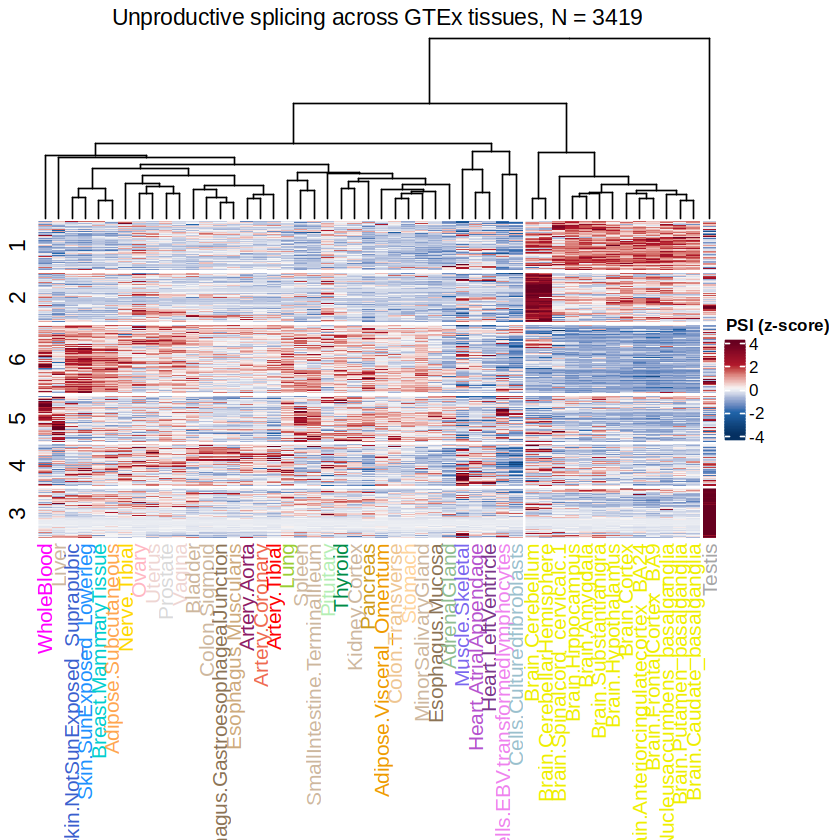

In [31]:
ht

In [59]:
gtex_colors <- list(
  "Adipose - Subcutaneous" = list(
    "tissue_abbrv" = "ADPSBQ", 
    "tissue_color_hex" = "FFA54F", 
    "tissue_color_rgb" = "255,165,79"
  ), 
  "Adipose - Visceral (omentum)" = list(
    "tissue_abbrv" = "ADPVSC", 
    "tissue_color_hex" = "EE9A00", 
    "tissue_color_rgb" = "238,154,0"
  ), 
  "Adrenal gland" = list(
    "tissue_abbrv" = "ADRNLG", 
    "tissue_color_hex" = "8FBC8F", 
    "tissue_color_rgb" = "143,188,143"
  ), 
  "Artery - Aorta" = list(
    "tissue_abbrv" = "ARTAORT", 
    "tissue_color_hex" = "8B1C62", 
    "tissue_color_rgb" = "139,28,98"
  ), 
  "Artery - Coronary" = list(
    "tissue_abbrv" = "ARTCRN", 
    "tissue_color_hex" = "EE6A50", 
    "tissue_color_rgb" = "238,106,80"
  ), 
  "Artery - Femoral" = list(
    "tissue_abbrv" = "ARTFMR", 
    "tissue_color_hex" = "FF4500", 
    "tissue_color_rgb" = "255,69,0"
  ), 
  "Artery - Tibial" = list(
    "tissue_abbrv" = "ARTTBL", 
    "tissue_color_hex" = "FF0000", 
    "tissue_color_rgb" = "255,0,0"
  ), 
  "Bladder" = list(
    "tissue_abbrv" = "BLDDER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Brain - Amygdala" = list(
    "tissue_abbrv" = "BRNAMY", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Anterior cingulate cortex (BA24)" = list(
    "tissue_abbrv" = "BRNACC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Caudate (basal ganglia)" = list(
    "tissue_abbrv" = "BRNCDT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cerebellar hemisphere" = list(
    "tissue_abbrv" = "BRNCHB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cerebellum" = list(
    "tissue_abbrv" = "BRNCHA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cortex" = list(
    "tissue_abbrv" = "BRNCTXA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Frontal cortex (BA9)" = list(
    "tissue_abbrv" = "BRNCTXB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Hippocampus" = list(
    "tissue_abbrv" = "BRNHPP", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Hypothalamus" = list(
    "tissue_abbrv" = "BRNHPT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Nucleus accumbens (basal ganglia)" = list(
    "tissue_abbrv" = "BRNNCC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Putamen (basal ganglia)" = list(
    "tissue_abbrv" = "BRNPTM", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Spinalcord (cervical c-1)" = list(
    "tissue_abbrv" = "BRNSPC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Substantia nigra" = list(
    "tissue_abbrv" = "BRNSNG", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Breast - Mammary tissue" = list(
    "tissue_abbrv" = "BREAST", 
    "tissue_color_hex" = "00CDCD", 
    "tissue_color_rgb" = "0,205,205"
  ), 
  "Cells - EBV-transformed lymphocytes" = list(
    "tissue_abbrv" = "LCL", 
    "tissue_color_hex" = "EE82EE", 
    "tissue_color_rgb" = "238,130,238"
  ), 
  "Cells - Cultured fibroblasts" = list(
    "tissue_abbrv" = "FIBRBLS", 
    "tissue_color_hex" = "9AC0CD", 
    "tissue_color_rgb" = "154,192,205"
  ), 
  "Cervix - Ectocervix" = list(
    "tissue_abbrv" = "CVXECT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Cervix - Endocervix" = list(
    "tissue_abbrv" = "CVSEND", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Colon - Sigmoid" = list(
    "tissue_abbrv" = "CLNSGM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Colon - Transverse" = list(
    "tissue_abbrv" = "CLNTRN", 
    "tissue_color_hex" = "EEC591", 
    "tissue_color_rgb" = "238,197,145"
  ), 
  "Esophagus - Gastroesophageal junction" = list(
    "tissue_abbrv" = "ESPGEJ", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus - Mucosa" = list(
    "tissue_abbrv" = "ESPMCS", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus - Muscularis" = list(
    "tissue_abbrv" = "ESPMSL", 
    "tissue_color_hex" = "CDAA7D", 
    "tissue_color_rgb" = "205,170,125"
  ), 
  "Fallopian tube" = list(
    "tissue_abbrv" = "FLLPNT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Heart - Atrial appendage" = list(
    "tissue_abbrv" = "HRTAA", 
    "tissue_color_hex" = "B452CD", 
    "tissue_color_rgb" = "180,82,205"
  ), 
  "Heart - Left ventricle" = list(
    "tissue_abbrv" = "HRTLV", 
    "tissue_color_hex" = "7A378B", 
    "tissue_color_rgb" = "122,55,139"
  ), 
  "Kidney - Cortex" = list(
    "tissue_abbrv" = "KDNCTX", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Kidney - Medulla" = list(
    "tissue_abbrv" = "KDNMDL", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Liver" = list(
    "tissue_abbrv" = "LIVER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Lung" = list(
    "tissue_abbrv" = "LUNG", 
    "tissue_color_hex" = "9ACD32", 
    "tissue_color_rgb" = "154,205,50"
  ), 
  "Minor salivary gland" = list(
    "tissue_abbrv" = "SLVRYG", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Muscle - Skeletal" = list(
    "tissue_abbrv" = "MSCLSK", 
    "tissue_color_hex" = "7A67EE", 
    "tissue_color_rgb" = "122,103,238"
  ), 
  "Nerve - Tibial" = list(
    "tissue_abbrv" = "NERVET", 
    "tissue_color_hex" = "FFD700", 
    "tissue_color_rgb" = "255,215,0"
  ), 
  "Ovary" = list(
    "tissue_abbrv" = "OVARY", 
    "tissue_color_hex" = "FFB6C1", 
    "tissue_color_rgb" = "255,182,193"
  ), 
  "Pancreas" = list(
    "tissue_abbrv" = "PNCREAS", 
    "tissue_color_hex" = "CD9B1D", 
    "tissue_color_rgb" = "205,155,29"
  ), 
  "Pituitary" = list(
    "tissue_abbrv" = "PTTARY", 
    "tissue_color_hex" = "B4EEB4", 
    "tissue_color_rgb" = "180,238,180"
  ), 
  "Prostate" = list(
    "tissue_abbrv" = "PRSTTE", 
    "tissue_color_hex" = "D9D9D9", 
    "tissue_color_rgb" = "217,217,217"
  ), 
  "Skin - Not sun exposed (suprapubic)" = list(
    "tissue_abbrv" = "SKINNS", 
    "tissue_color_hex" = "3A5FCD", 
    "tissue_color_rgb" = "58,95,205"
  ), 
  "Skin - Sun exposed (lower leg)" = list(
    "tissue_abbrv" = "SKINS", 
    "tissue_color_hex" = "1E90FF", 
    "tissue_color_rgb" = "30,144,255"
  ), 
  "Small intestine - Terminal ileum" = list(
    "tissue_abbrv" = "SNTTRM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Spleen" = list(
    "tissue_abbrv" = "SPLEEN", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Stomach" = list(
    "tissue_abbrv" = "STMACH", 
    "tissue_color_hex" = "FFD39B", 
    "tissue_color_rgb" = "255,211,155"
  ), 
  "Testis" = list(
    "tissue_abbrv" = "TESTIS", 
    "tissue_color_hex" = "A6A6A6", 
    "tissue_color_rgb" = "166,166,166"
  ), 
  "Thyroid" = list(
    "tissue_abbrv" = "THYROID", 
    "tissue_color_hex" = "008B45", 
    "tissue_color_rgb" = "0,139,69"
  ), 
  "Uterus" = list(
    "tissue_abbrv" = "UTERUS", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Vagina" = list(
    "tissue_abbrv" = "VAGINA", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Whole blood" = list(
    "tissue_abbrv" = "WHLBLD", 
    "tissue_color_hex" = "FF00FF", 
    "tissue_color_rgb" = "255,0,255"
  )
)

In [79]:
up_psi

,intron,cluster,itype,ctype,gene_name,gene_id,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr10:100190968:100192458:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.0830389521,0.2407215680,0.1576749749,8.753754e-02,⋯,0.128513713,2.517681e-02,0.119784245,6.349370e-02,0.0306761548,0.209774067,0.2089986449,0.158868440,0.1658607010,0.042327018
2,chr10:100190968:100193388:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.0187991722,0.0139744120,0.0105147510,1.581324e-02,⋯,0.015678992,1.074553e-02,0.013978630,1.571402e-02,0.0097862207,0.007654834,0.0147767594,0.017518663,0.0105282523,0.019714040
3,chr10:100496431:100497666:clu_24486_-,chr10:clu_24486_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.0724130949,0.0335015945,0.0278579914,2.824943e-02,⋯,0.046129174,6.098257e-02,0.027780633,3.587937e-02,0.0475081311,0.099586731,0.0616321571,0.060940716,0.0457710184,0.061426941
4,chr10:100498207:100499159:clu_24487_-,chr10:clu_24487_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.2903566590,0.2475714295,0.2408751219,2.417582e-01,⋯,0.274270738,1.805201e-01,0.211172139,1.859468e-01,0.2087604874,0.112935032,0.3015598773,0.245051415,0.2907946237,0.174686816
5,chr10:100499598:100500109:clu_24489_-,chr10:clu_24489_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.2925359714,0.1932268198,0.2161216724,3.333732e-01,⋯,0.298539935,2.496546e-01,0.340211933,3.210916e-01,0.3289088184,0.235171554,0.3016240295,0.277442169,0.2732430602,0.308342210
6,chr10:100500159:100501653:clu_24489_-,chr10:clu_24489_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.0198316885,0.0121058777,0.0114142768,2.377158e-02,⋯,0.025705299,2.256364e-02,0.025307736,2.808938e-02,0.0266000721,0.011182153,0.0200733426,0.025766692,0.0226865145,0.051886185
7,chr10:100500159:100502253:clu_24489_-,chr10:clu_24489_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.3497426399,0.2080576272,0.2367899689,3.657433e-01,⋯,0.310000473,2.806946e-01,0.366285839,3.487636e-01,0.3487910640,0.263440839,0.3216138856,0.294298794,0.2883121341,0.306227447
8,chr10:100501710:100502253:clu_24489_-,chr10:clu_24489_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.0209077756,0.0109099374,0.0097369867,2.159134e-02,⋯,0.028247605,2.172668e-02,0.021838522,2.633038e-02,0.0239713447,0.008932081,0.0194965340,0.019885354,0.0267613337,0.048971140
9,chr10:100508048:100508460:clu_24491_-,chr10:clu_24491_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.0009771331,0.1206386417,0.0488193401,3.295422e-04,⋯,0.001027095,2.806301e-06,0.001713852,1.777032e-03,0.0029534724,0.002395735,0.0023793146,0.002206053,0.0011308290,0.002844602


In [67]:
colnames(X) <- c(
    'Artery - Aorta', 'Brain - Cortex', 'Brain - Nucleus accumbens (basal ganglia)', 'Esophagus - Muscularis', 
    'Adipose - Visceral (omentum)', 'Adrenal gland', 'Artery - Coronary', 'Bladder', 'Brain - Amygdala', 
    'Brain - Anterior cingulate cortex (BA24)', 'Brain - Caudate (basal ganglia)', 'Brain - Cerebellar hemisphere', 
    'Brain - Cerebellum', 'Brain - Hypothalamus', 'Brain - Putamen (basal ganglia)', 'Brain - Spinalcord (cervical c-1)', 
    'Brain - Substantia nigra', 'Cells - Cultured fibroblasts', 'Esophagus - Gastroesophageal junction', 
    'Esophagus - Mucosa', 'Heart - Atrial appendage', 
    'Heart - Left ventricle', 'Kidney - Cortex', 'Lung', 'Minor salivary gland', 'Ovary', 'Pancreas', 'Pituitary', 
    'Prostate', 'Small intestine - Terminal ileum', 'Spleen', 'Stomach', 'Testis', 'Thyroid', 'Uterus', 'Vagina', 
    'Adipose - Subcutaneous', 'Artery - Tibial', 'Brain - Frontal cortex (BA9)', 'Brain - Hippocampus', 
    'Breast - Mammary tissue', 'Cells - EBV-transformed lymphocytes', 'Colon - Sigmoid', 'Colon - Transverse', 
    'Liver', 'Muscle - Skeletal', 'Nerve - Tibial', 'Skin - Not sun exposed (suprapubic)', 
    'Skin - Sun exposed (lower leg)', 'Whole blood'
)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



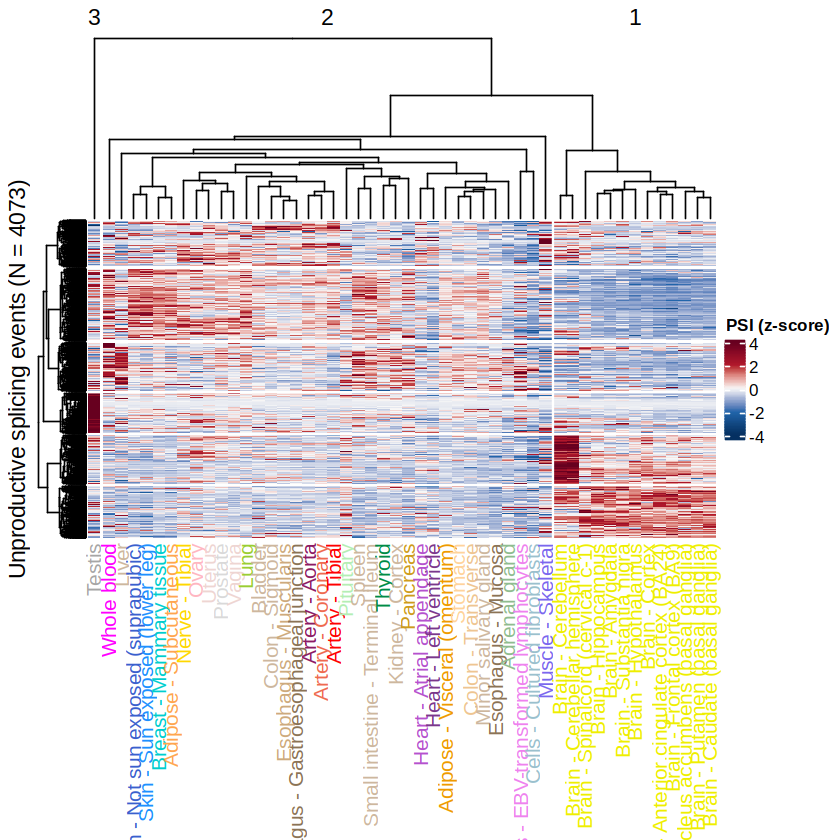

In [81]:
library(ComplexHeatmap)
library(glue)
library(dplyr)

legendBreaks <- seq(-4, 4, 2)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )


column_colors <- sapply(colnames(X), function(tissue) {
  paste0("#", gtex_colors[[tissue]]$tissue_color_hex)
})

# Create the heatmap
set.seed(2)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>%
  Heatmap(
    row_title = glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, 
    column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = TRUE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    column_names_gp = gpar(col = column_colors)
  )

ht

In [75]:
# Define column colors
column_colors <- setNames(
  sapply(colnames(X), function(tissue) paste0("#", gtex_colors[[tissue]]$tissue_color_hex)),
  colnames(X)
)

# Create a heatmap annotation
column_ha <- HeatmapAnnotation(
  Tissue = colnames(X),
  col = list(Tissue = column_colors),
  show_legend = FALSE  # Hide legend if unnecessary
)

# Create the heatmap
set.seed(2)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% 
  Heatmap(
    row_title = glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = FALSE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

    
# pdf("heatmap_output.pdf", 
pdf("../code/plots/fig2_heatmap.pdf",  width = 12, height = 15)  # Set dimensions as needed
draw(ht, raster_quality = 2)  # Lower value = higher quality
dev.off()
    
# pdf("../code/plots/fig2_heatmap.pdf",  width = 12, height = 15)  # Set dimensions as needed
# draw(ht, raster_quality = 2)  # Lower value = higher quality
# dev.off()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

In [85]:
up_psi %>% pull(cluster) %>% unique() %>% length()

[1] 2397

In [92]:
cluster_df

intron,Cluster
<chr>,<int>
chr9:137575892:137576079:clu_22957_-,1
chr17:44438715:44464471:clu_39181_-,1
chr17:44436545:44438670:clu_39181_-,1
chr11:95778957:95779077:clu_27178_-,1
chr10:49908541:49915916:clu_24144_-,1
chr15:43631538:43632198:clu_33771_-,1
chr11:95778954:95779077:clu_27178_-,1
chr7:99061837:99120642:clu_18937_-,1
chr4:992230:1000611:clu_10969_+,1


In [94]:
X_merge <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% as.data.frame()

In [96]:
X_merge['intron'] <- rownames(X)

In [99]:


up_psi_norm <- merge(up_psi[c('intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id')], 
      X_merge, by = c("intron"))

In [100]:
row_clusters <- row_order(ht)

# Convert list to a data frame for easy interpretation
cluster_df <- do.call(rbind, lapply(seq_along(row_clusters), function(i) {
  data.frame(intron = rownames(X)[row_clusters[[i]]], Cluster = i)
}))

# View the first few rows
head(cluster_df)

up_psi_filter <- up_psi_norm %>% filter(intron %in% cluster_df$intron)
up_psi_filter <- merge(up_psi_filter, cluster_df, by = c("intron"))
up_psi_filter %>% write_tsv(., 'UP_clusters.tsv')

Warning message:
"The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`."


,intron,Cluster
,<chr>,<int>
1,chr14:61078927:61083549:clu_31358_+,1
2,chr1:112578417:112591524:clu_3518_-,1
3,chr12:4543911:4545218:clu_27548_+,1
4,chr14:45096228:45096423:clu_31216_+,1
5,chr16:23546434:23552148:clu_36127_-,1
6,chr16:23544703:23546381:clu_36127_-,1


In [77]:
up_psi_filter %>% pull(Cluster) %>% table

.
  1   2   3   4   5   6 
680 683 835 844 491 540 

In [41]:
comparisons <- sub("\\.rds$", "", list.files('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'))
comparison <- comparisons[1]
path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'
rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))

In [61]:
sig_genes <- rds$dge %>% filter(padj <= 5e-2, abs(log2FoldChange) >= 0.1) %>% pull(gene_id) %>% unique()
sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.1, p.adjust <= 5e-2, itype=='UP', ctype=='PR,UP',
                                 gene_id %in% sig_genes) %>% pull(cluster) %>% unique()

In [62]:
sig_clusters %>% length()

[1] 190